# 03 — Fibrotic Niche Ring Analysis

This notebook measures spatial proximity to the closest fibrotic niche on the native 10x Genomics Visium hexagonal lattice.

For each IPF tissue section, fibrotic-niche spots are treated as distance zero. A multi-source breadth-first search then assigns every connected tissue spot its shortest graph distance to the nearest fibrotic spot. Cell-type abundance, gene expression, and pathway activity are summarized across these spatial rings.

This notebook is descriptive. Formal models that separate fibrotic composition from spatial proximity are introduced in Notebook 04.

In [39]:
import warnings
from collections import deque

warnings.filterwarnings(
    "ignore",
    message=r"IProgress not found.*",
    category=Warning,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")
sns.set_theme(style="whitegrid", context="notebook")

## Load the processed dataset

In [40]:
adata = sc.read_h5ad("../data/adata_vis_human_spatial_paper.h5ad")
adata

AnnData object with n_obs × n_vars = 57787 × 12486
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden_25', 'sampleID', 'treatment', 'VisiumSlides', 'technology', 'patient', 'AT0', 'AT1', 'AT2', 'Aberrant basaloid', 'Adventitial fibroblast', 'Alveolar fibroblast', 'Artery', 'B/Plasma', 'Basal', 'Basophil/Mast', 'Bronchial Vessel', 'Capillary', 'Capillary Aerocyte', 'Ciliated', 'Ciliated SFTPB+/SCGB1A1+', 'Dendritic', 'Ionocyte', 'Lymphatic', 'Macrophage C1Q hi', 'Macrophage CHI3L1+/CD9 hi/', 'Macrophage FABP4+', 'Macrophage IL1B+', 'Macrophage LYVE1+', 'Macrophage RETN+/VCAN+', 'Mesothelial', 'Monocyte', 'Mucous', 'Myofibroblast', 'NK', 'Peribronchial fibroblast', 'Pericyte', 'Smooth Muscle', 'T cell', 'TB-SC', 'Vein', 'pDC', 'preTB-SC/RAS', 'Androgen', 'EGFRsignaling', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'p53', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'mean_nUMI_fa

## Select IPF sections with fibrotic-niche spots

Ring distance is defined only for IPF sections that contain at least one spot labeled `Fibrotic`. Healthy sections are not used as ring-analysis replicates.

In [41]:
sample_overview = (
    adata.obs.groupby(["sample", "treatment"], observed=True)
    .agg(
        total_spots=("Niche_NMF", "size"),
        fibrotic_spots=("Niche_NMF", lambda values: (values == "Fibrotic").sum()),
    )
    .reset_index()
)

ipf_samples = sample_overview.loc[
    (sample_overview["treatment"] == "IPF")
    & (sample_overview["fibrotic_spots"] > 0),
    "sample",
].tolist()

sample_overview

,sample,treatment,total_spots,fibrotic_spots
0,90_A1_H237762_IPF_processed_CM,IPF,2793,161
1,90_C1_RO-730_Healthy_processed_CM,Healthy,2877,0
2,91_A1_RO-727_Healthy_processed_CM,Healthy,2377,0
3,91_B1_RO-728_Healthy_processed_CM,Healthy,2448,13
4,91_D1_24513-17_IPF_processed_CM,IPF,3284,302
5,92_D1_RO-3736_IPF_processed_CM,IPF,1931,390
6,92_A1_RO-3203_Healthy_processed_CM,Healthy,2412,0
7,1217_0001_processed_aligned,IPF,10728,572
8,1217_0002_processed_aligned,Healthy,8624,0
9,1217_0003_processed_aligned,IPF,12107,1392


In [42]:
print(f"IPF sections included: {len(ipf_samples)}")
ipf_samples

IPF sections included: 5


['90_A1_H237762_IPF_processed_CM',
 '91_D1_24513-17_IPF_processed_CM',
 '92_D1_RO-3736_IPF_processed_CM',
 '1217_0001_processed_aligned',
 '1217_0003_processed_aligned']

## Construct the Visium hexagonal-lattice graph

In 10x Visium array coordinates, each spot can have six immediate neighbors:

```text
(row, col ± 2)
(row ± 1, col ± 1)
```

The graph is built separately inside every physical tissue section. Missing tissue positions remain missing and cannot be crossed by the shortest path.

In [43]:
VISIUM_NEIGHBOR_OFFSETS = (
    (0, -2),
    (0, 2),
    (-1, -1),
    (-1, 1),
    (1, -1),
    (1, 1),
)


def distance_to_fibrotic_niche(section_obs):
    """Shortest hex-lattice distance to any Fibrotic spot in one section."""
    rows = section_obs["array_row"].astype(int).to_numpy()
    cols = section_obs["array_col"].astype(int).to_numpy()
    coordinates = list(zip(rows, cols))
    coordinate_to_position = {
        coordinate: position
        for position, coordinate in enumerate(coordinates)
    }

    distances = np.full(len(section_obs), np.inf)
    fibrotic_positions = np.flatnonzero(
        section_obs["Niche_NMF"].to_numpy() == "Fibrotic"
    )

    queue = deque(fibrotic_positions.tolist())
    distances[fibrotic_positions] = 0

    while queue:
        position = queue.popleft()
        row, col = coordinates[position]
        next_distance = distances[position] + 1

        for row_offset, col_offset in VISIUM_NEIGHBOR_OFFSETS:
            neighbor = (row + row_offset, col + col_offset)
            neighbor_position = coordinate_to_position.get(neighbor)

            if neighbor_position is None:
                continue

            if next_distance < distances[neighbor_position]:
                distances[neighbor_position] = next_distance
                queue.append(neighbor_position)

    return pd.Series(distances, index=section_obs.index, dtype=float)


## Calculate graph distance and define rings

- Ring 0: spots labeled as Fibrotic
- Rings 1–4: exact shortest lattice distances
- Ring 5+: five or more lattice steps from the nearest fibrotic spot

Disconnected spots, if present, remain unassigned rather than being given an artificial distance.

In [44]:
ring_distance = pd.Series(np.nan, index=adata.obs_names, dtype=float)

for sample in ipf_samples:
    section_obs = adata.obs.loc[adata.obs["sample"] == sample]
    ring_distance.loc[section_obs.index] = distance_to_fibrotic_niche(section_obs)

ring_distance = ring_distance.replace(np.inf, np.nan)
adata.obs["fibrotic_ring_distance"] = ring_distance

ring_order = ["0", "1", "2", "3", "4", "5+"]
ring_labels = pd.Series(pd.NA, index=adata.obs_names, dtype="object")
finite = adata.obs["fibrotic_ring_distance"].notna()
distance_values = adata.obs.loc[finite, "fibrotic_ring_distance"]

ring_labels.loc[finite] = np.where(
    distance_values >= 5,
    "5+",
    distance_values.astype(int).astype(str),
)

adata.obs["fibrotic_ring"] = pd.Categorical(
    ring_labels,
    categories=ring_order,
    ordered=True,
)

adata.obs.loc[
    adata.obs["sample"].isin(ipf_samples),
    ["sample", "Niche_NMF", "fibrotic_ring_distance", "fibrotic_ring"],
].head()

,sample,Niche_NMF,fibrotic_ring_distance,fibrotic_ring
spot_id,,,,
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1,90_A1_H237762_IPF_processed_CM,Fibroblast,4.0,4
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1,90_A1_H237762_IPF_processed_CM,Alveolar,2.0,2
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1,90_A1_H237762_IPF_processed_CM,Alveolar,1.0,1
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1,90_A1_H237762_IPF_processed_CM,SMCs_Adv_Meso,1.0,1
90_A1_H237762_IPF_processed_CM_AAACATTTCCCGGATT-1,90_A1_H237762_IPF_processed_CM,Fibroblast,4.0,4


In [45]:
ring_counts = (
    adata.obs.loc[adata.obs["sample"].isin(ipf_samples)]
    .groupby(["sample", "fibrotic_ring"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ring_order)
)

ring_counts

fibrotic_ring,0,1,2,3,4,5+
sample,,,,,,
90_A1_H237762_IPF_processed_CM,161,434,492,426,342,938
90_C1_RO-730_Healthy_processed_CM,0,0,0,0,0,0
91_A1_RO-727_Healthy_processed_CM,0,0,0,0,0,0
91_B1_RO-728_Healthy_processed_CM,0,0,0,0,0,0
91_D1_24513-17_IPF_processed_CM,302,594,556,468,374,988
92_D1_RO-3736_IPF_processed_CM,390,653,409,223,106,119
92_A1_RO-3203_Healthy_processed_CM,0,0,0,0,0,0
1217_0001_processed_aligned,572,1090,1309,1290,1168,5292
1217_0002_processed_aligned,0,0,0,0,0,0


In [46]:
unassigned_counts = (
    adata.obs.loc[adata.obs["sample"].isin(ipf_samples)]
    .groupby("sample", observed=True)["fibrotic_ring_distance"]
    .apply(lambda values: values.isna().sum())
)

print("Disconnected/unassigned spots by section:")
print(unassigned_counts.to_string())

Disconnected/unassigned spots by section:
sample
90_A1_H237762_IPF_processed_CM      0
91_D1_24513-17_IPF_processed_CM     2
92_D1_RO-3736_IPF_processed_CM     31
1217_0001_processed_aligned         7
1217_0003_processed_aligned         1


## Spatial quality control in a representative IPF section

The same representative IPF section used in the preceding notebooks is shown with its original niche labels and its newly calculated ring assignments.

In [47]:
sample = "90_A1_H237762_IPF_processed_CM"
adata_sample = adata[adata.obs["sample"] == sample].copy()

print(f"Selected sample: {sample}")
print(adata_sample.obs["fibrotic_ring"].value_counts(sort=False))

Selected sample: 90_A1_H237762_IPF_processed_CM
fibrotic_ring
0     161
1     434
2     492
3     426
4     342
5+    938
Name: count, dtype: int64


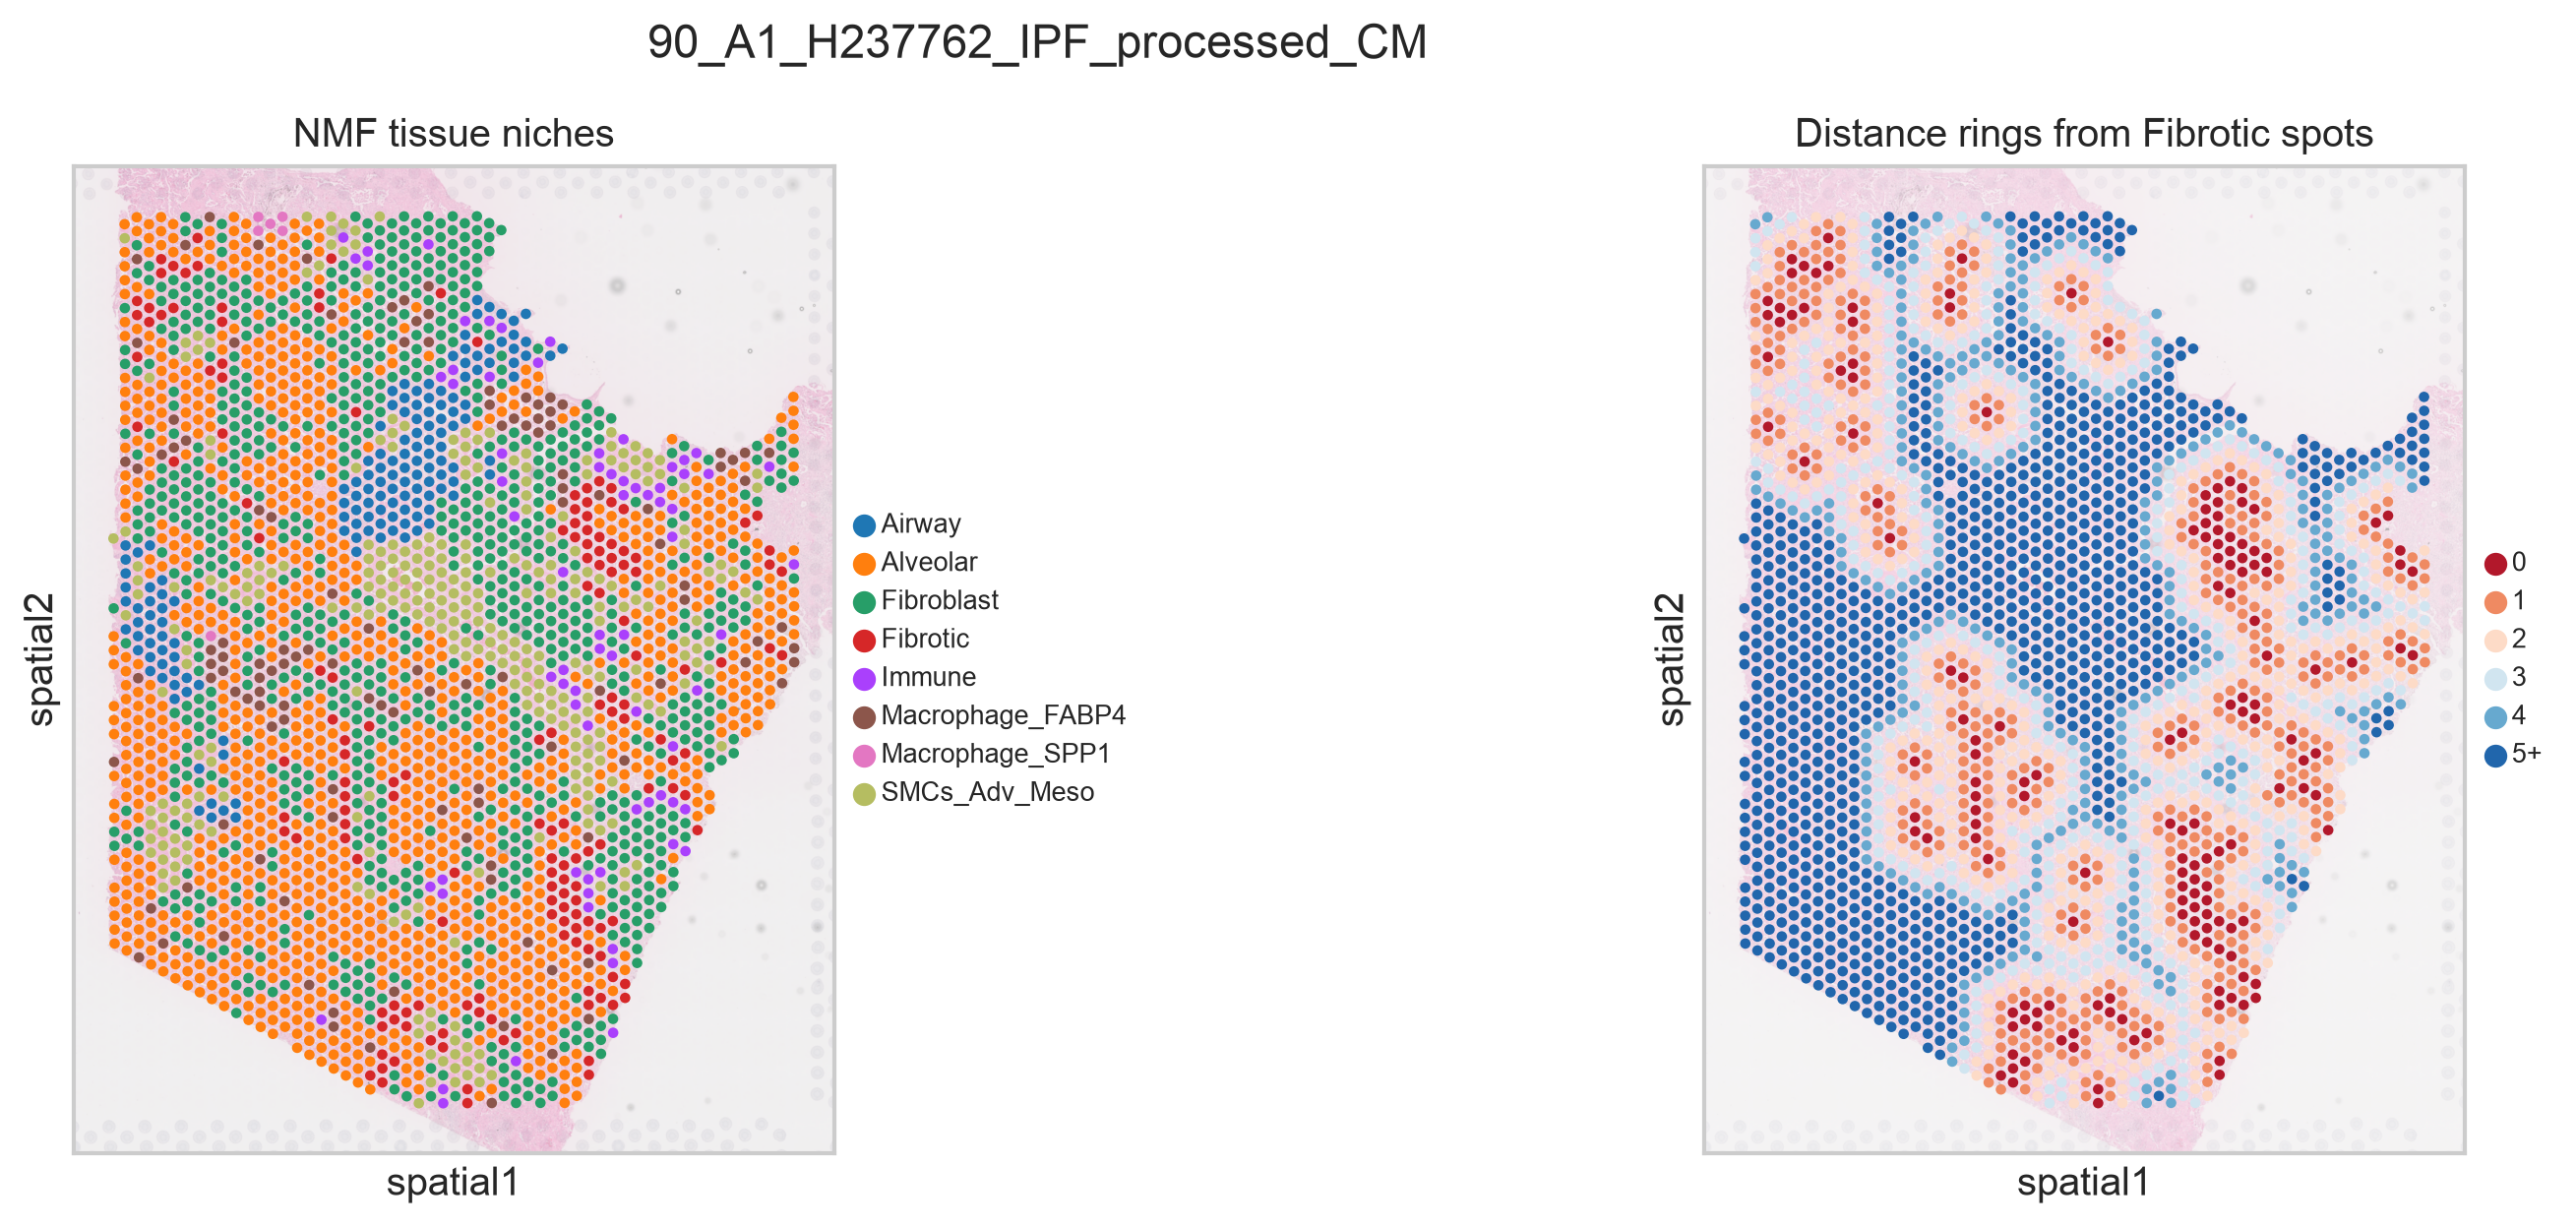

In [48]:
ring_palette = {
    "0": "#B2182B",
    "1": "#EF8A62",
    "2": "#FDDBC7",
    "3": "#D1E5F0",
    "4": "#67A9CF",
    "5+": "#2166AC",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    dpi=120,
    gridspec_kw={"wspace": 0.72},
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The function spatial is deprecated.*",
        category=FutureWarning,
    )

    sc.pl.spatial(
        adata_sample,
        color="Niche_NMF",
        library_id=sample,
        size=1.15,
        alpha_img=0.55,
        title="NMF tissue niches",
        legend_loc="right margin",
        legend_fontsize=8,
        frameon=True,
        ax=axes[0],
        show=False,
    )

    sc.pl.spatial(
        adata_sample,
        color="fibrotic_ring",
        library_id=sample,
        size=1.15,
        alpha_img=0.40,
        palette=ring_palette,
        title="Distance rings from Fibrotic spots",
        legend_loc="right margin",
        legend_fontsize=8,
        frameon=True,
        ax=axes[1],
        show=False,
    )

for ax in axes:
    ax.set_xlabel("spatial1")
    ax.set_ylabel("spatial2")

fig.suptitle(sample, fontsize=14, y=1.02)
plt.show()

### Spatial interpretation

The discrete niche map shows where the eight NMF-defined multicellular environments occur in the representative IPF section. The accompanying ring map converts proximity to the nearest `Fibrotic` spot into an ordered spatial coordinate: Fibrotic spots are distance 0, followed by successive Visium-lattice rings.

Fibrotic spots form localized regions rather than being uniformly distributed across the section. The rings therefore provide a practical framework for asking whether cell composition and molecular programs change progressively from the fibrotic core toward surrounding tissue. Ring number measures graph distance between spots; it is not a physical micrometre measurement and does not by itself establish biological direction or causality.

## Helper functions for ring-gradient summaries

Measurements are first averaged within each `sample × ring`. The heatmaps then show row-wise z-scores calculated across rings, so color represents the spatial pattern of each feature rather than its absolute measurement scale.

In [49]:
def aggregate_by_sample_and_ring(values, value_name):
    frame = pd.DataFrame({
        "sample": adata.obs["sample"],
        "ring": adata.obs["fibrotic_ring"],
        value_name: values,
    })

    frame = frame.loc[
        frame["sample"].isin(ipf_samples)
        & frame["ring"].notna()
    ]

    return (
        frame.groupby(["sample", "ring"], observed=True)[value_name]
        .mean()
        .reset_index()
    )


def plot_ring_heatmap(
    summary,
    feature_column,
    value_column,
    feature_order,
    title,
    ylabel,
    figsize,
):
    matrix = (
        summary.groupby([feature_column, "ring"], observed=True)[value_column]
        .mean()
        .unstack("ring")
        .reindex(index=feature_order, columns=ring_order)
    )

    row_zscore = matrix.sub(matrix.mean(axis=1), axis=0).div(
        matrix.std(axis=1, ddof=0).replace(0, np.nan),
        axis=0,
    ).clip(-2, 2)

    display_columns = [
        "Fibrotic" if ring == "0" else f"Ring {ring}"
        for ring in row_zscore.columns
    ]
    row_zscore.columns = display_columns

    plt.figure(figsize=figsize, dpi=110)
    sns.heatmap(
        row_zscore,
        cmap="RdBu_r",
        center=0,
        vmin=-2,
        vmax=2,
        cbar_kws={"label": "Row-wise z-score"},
    )
    plt.title(title + "\nAll IPF sections")
    plt.xlabel("Visium spot-ring distance from Fibrotic niche")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return matrix, row_zscore


def plot_selected_ring_lines(
    summary,
    feature_column,
    value_column,
    feature_order,
    title,
    ylabel,
    ncols,
):
    selected = summary.loc[summary[feature_column].isin(feature_order)].copy()
    selected[feature_column] = pd.Categorical(
        selected[feature_column],
        categories=feature_order,
        ordered=True,
    )

    nrows = int(np.ceil(len(feature_order) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.1 * ncols, 3.3 * nrows),
        dpi=100,
        constrained_layout=True,
        squeeze=False,
    )

    for feature, ax in zip(feature_order, axes.flat):
        feature_data = selected.loc[selected[feature_column] == feature]

        sns.lineplot(
            data=feature_data,
            x="ring",
            y=value_column,
            estimator="mean",
            errorbar="se",
            marker="o",
            color="#B2182B",
            linewidth=2,
            ax=ax,
        )

        ax.set_title(feature)
        ax.set_xlabel("Distance ring")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=45)

    for ax in axes.flat[len(feature_order):]:
        ax.set_visible(False)

    fig.suptitle(title + "\nAll IPF sections", fontsize=15, y=1.03)
    plt.show()


## Cell-type abundance gradients

Representative stromal, epithelial, and immune populations are summarized across rings using the precomputed cell2location abundance estimates.

In [50]:
cell_types = [
    "Basal",
    "Aberrant basaloid",
    "Myofibroblast",
    "Macrophage C1Q hi",
    "Macrophage CHI3L1+/CD9 hi/",
    "Monocyte",
    "Macrophage IL1B+",
    "Macrophage RETN+/VCAN+",
    "TB-SC",
    "Dendritic",
    "Ionocyte",
    "Macrophage LYVE1+",
    "Smooth Muscle",
    "Adventitial fibroblast",
    "Ciliated",
    "Ciliated SFTPB+/SCGB1A1+",
    "Mucous",
    "Peribronchial fibroblast",
    "NK",
    "T cell",
    "AT0",
    "AT1",
    "Artery",
    "Capillary",
    "Pericyte",
    "Bronchial Vessel",
    "Lymphatic",
    "Mesothelial",
    "AT2",
    "Macrophage FABP4+",
    "preTB-SC/RAS",
    "Basophil/Mast",
    "Vein",
    "pDC",
    "B/Plasma",
    "Alveolar fibroblast",
    "Capillary Aerocyte",
]
cell_types = [cell_type for cell_type in cell_types if cell_type in adata.obs]

cell_ring_summaries = []

for cell_type in cell_types:
    summary = aggregate_by_sample_and_ring(
        adata.obs[cell_type],
        "mean_abundance",
    )
    summary["cell_type"] = cell_type
    cell_ring_summaries.append(summary)

cell_ring_summary = pd.concat(cell_ring_summaries, ignore_index=True)
cell_ring_summary.head()

,sample,ring,mean_abundance,cell_type
0,90_A1_H237762_IPF_processed_CM,0,0.009186,Basal
1,90_A1_H237762_IPF_processed_CM,1,0.007593,Basal
2,90_A1_H237762_IPF_processed_CM,2,0.017377,Basal
3,90_A1_H237762_IPF_processed_CM,3,0.037523,Basal
4,90_A1_H237762_IPF_processed_CM,4,0.043093,Basal


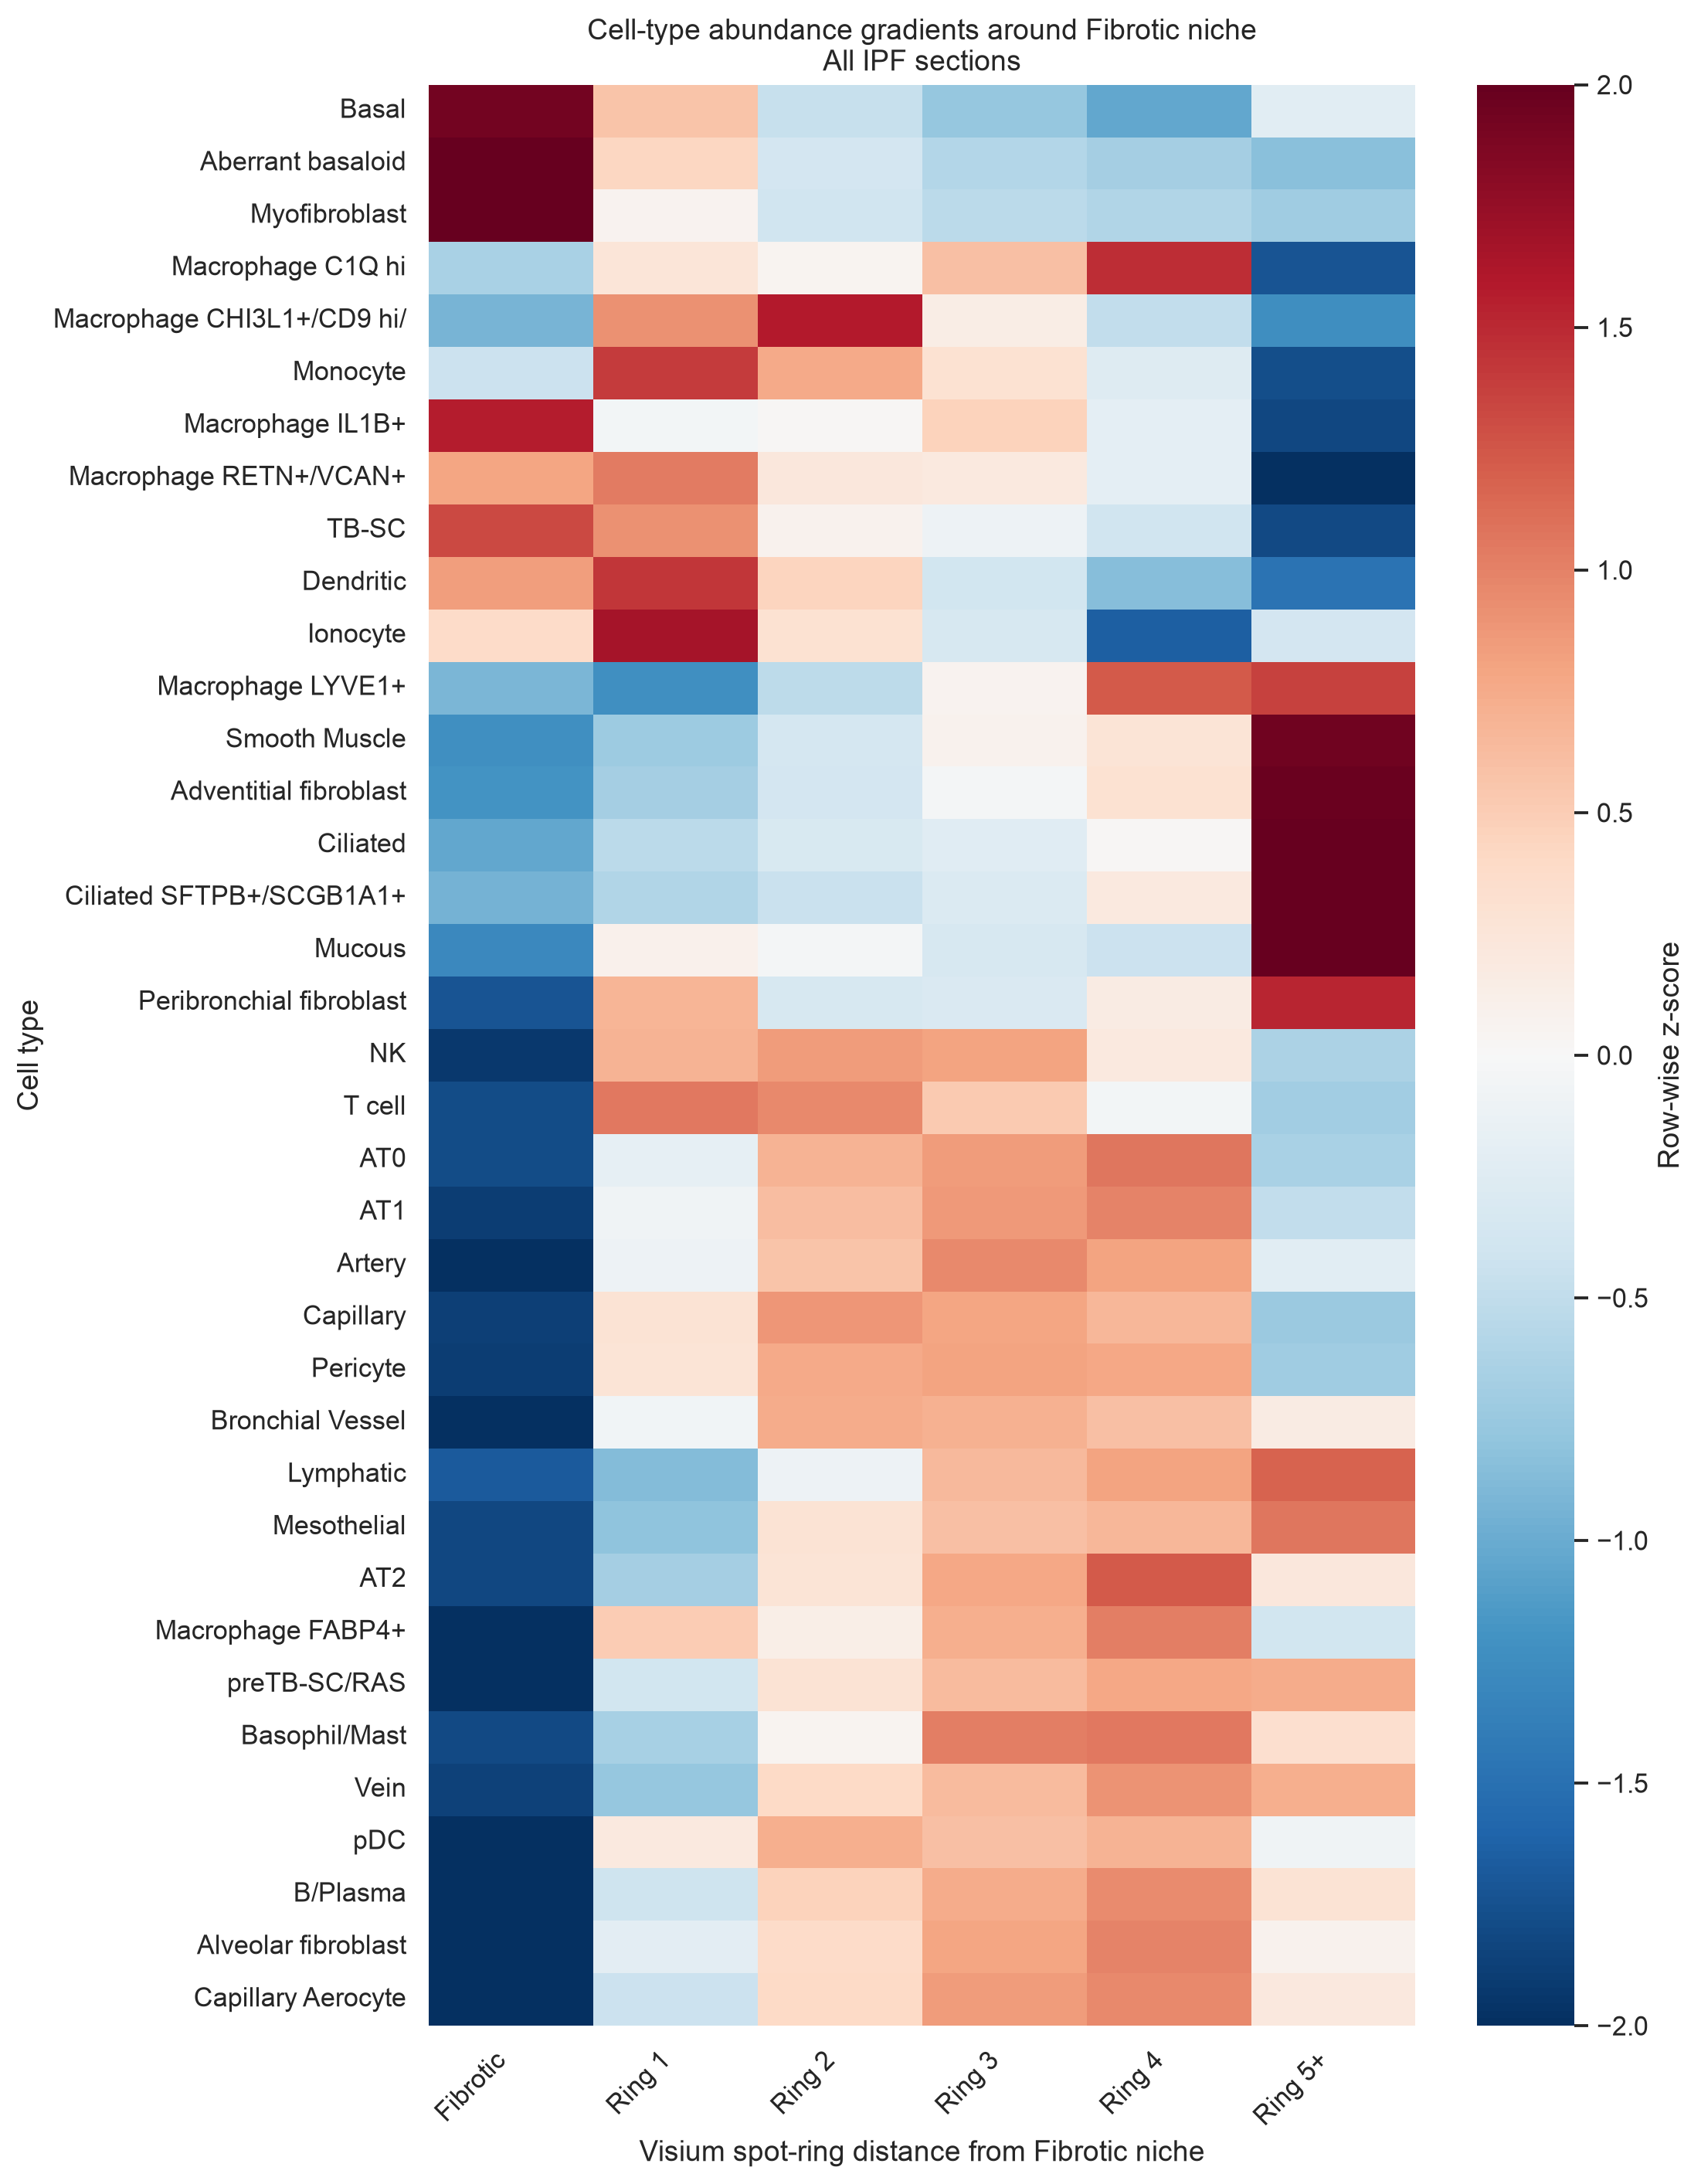

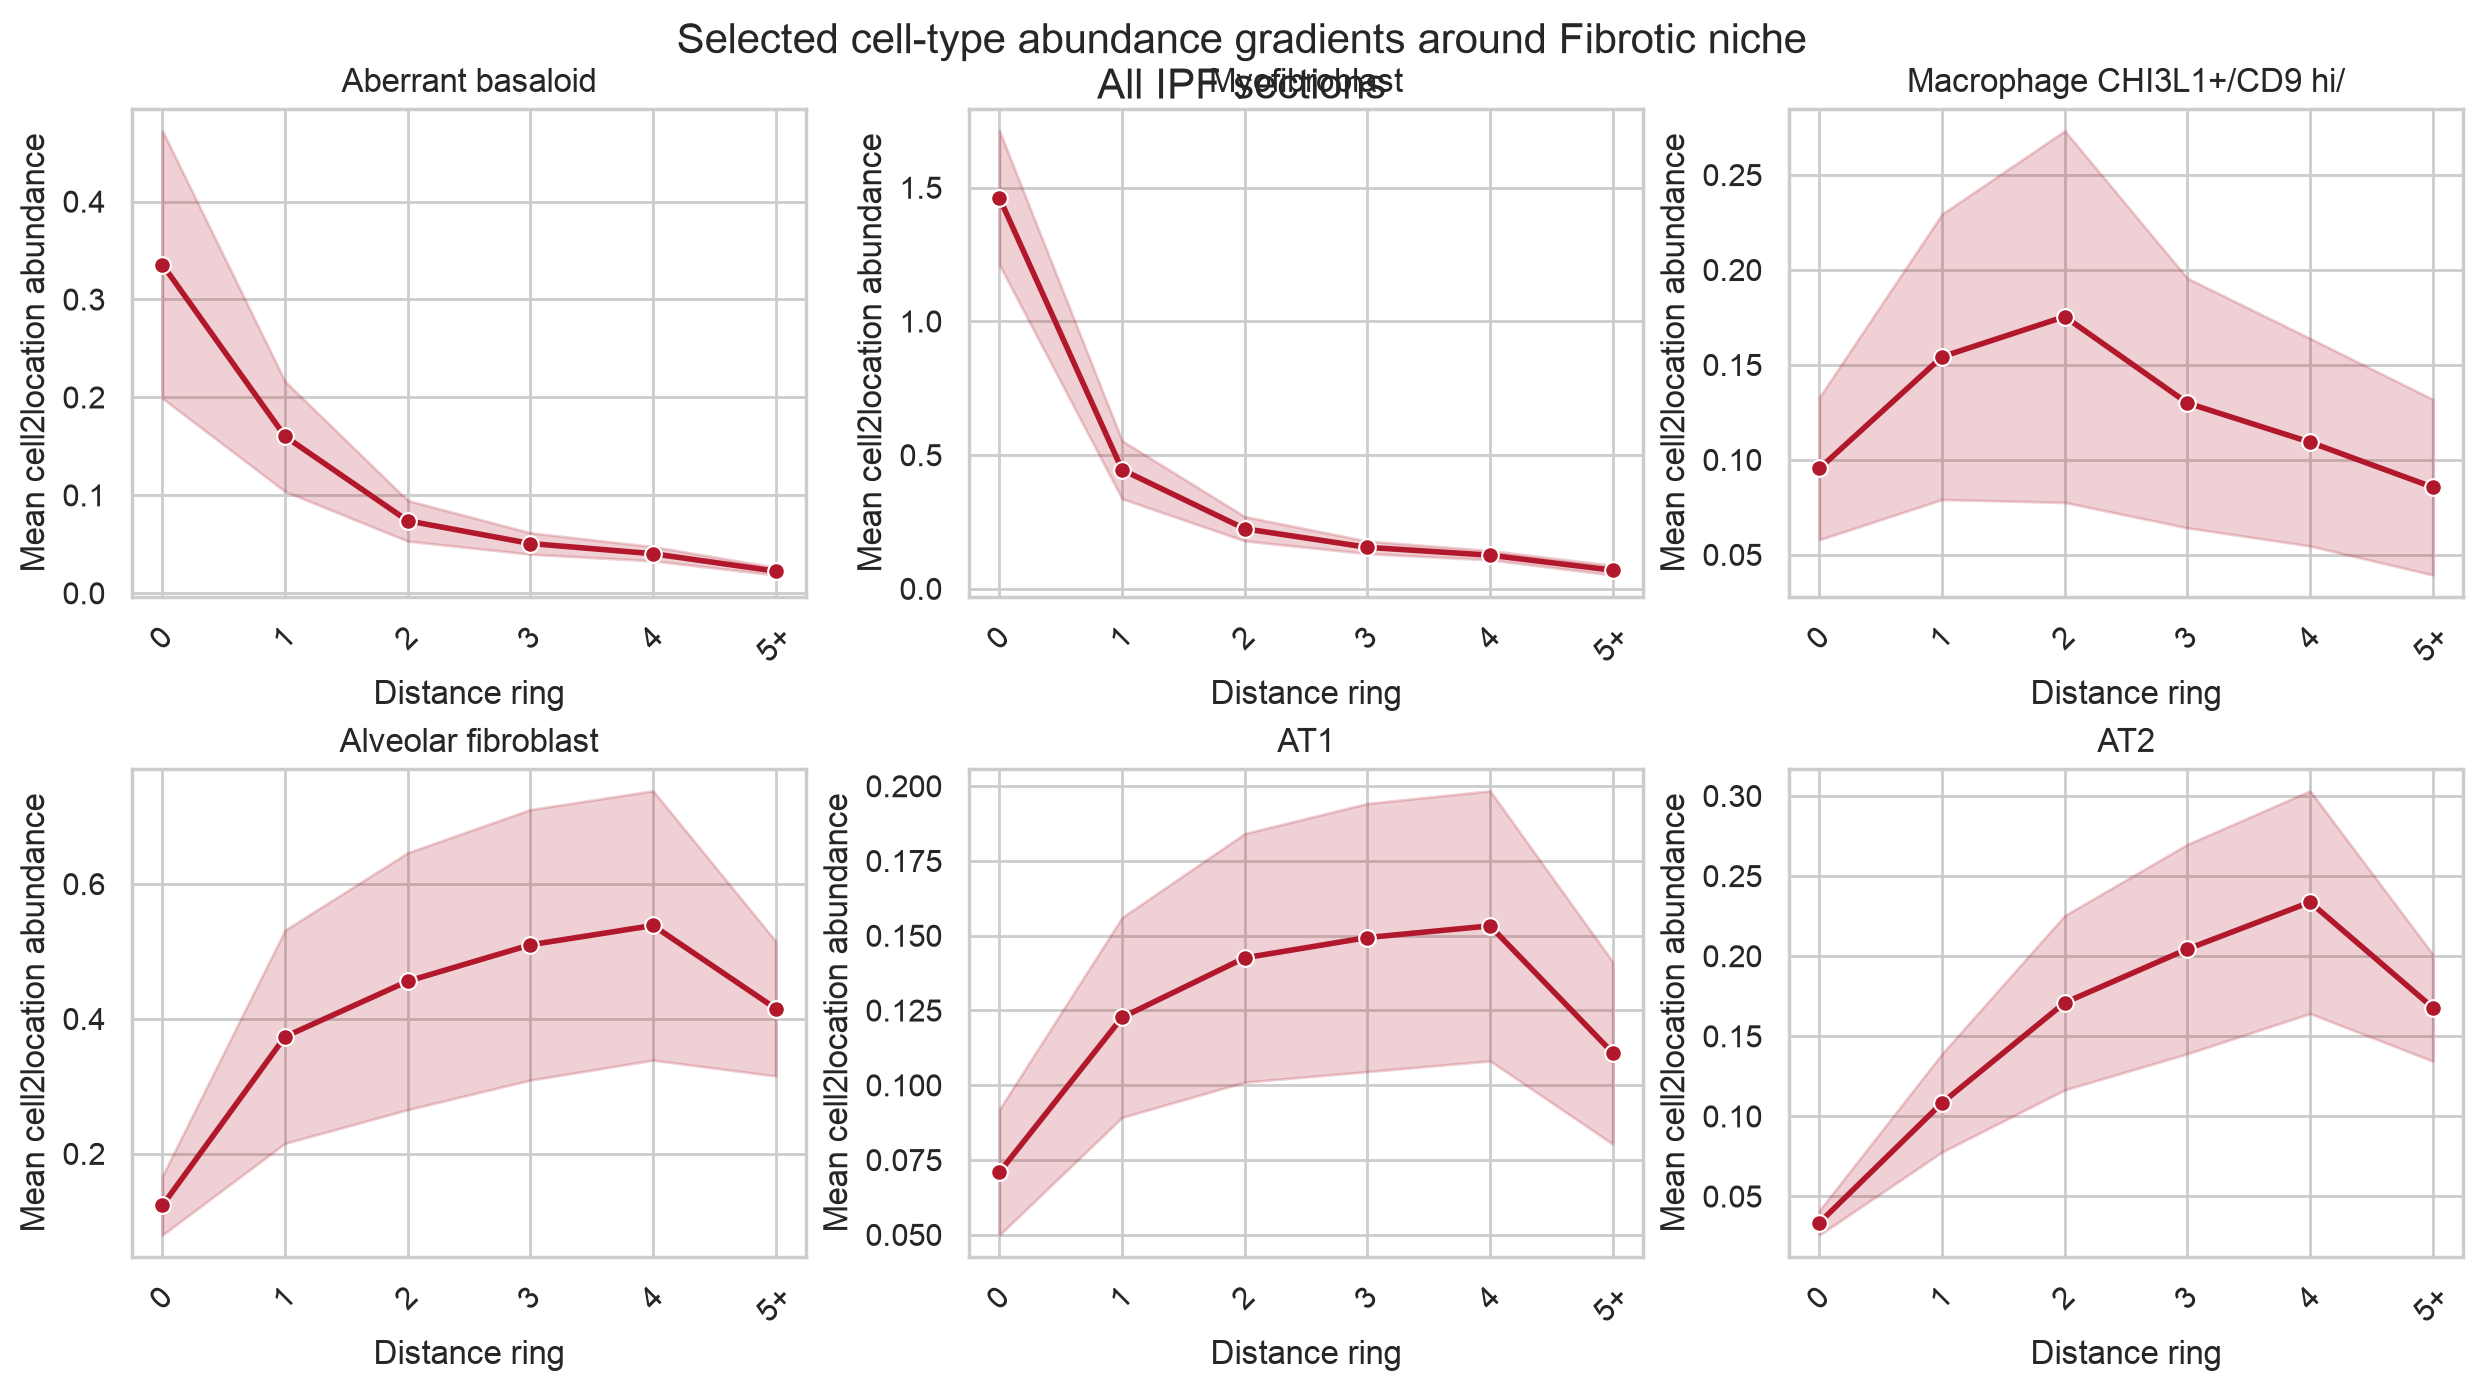

In [51]:
cell_ring_matrix, cell_ring_zscore = plot_ring_heatmap(
    cell_ring_summary,
    feature_column="cell_type",
    value_column="mean_abundance",
    feature_order=cell_types,
    title="Cell-type abundance gradients around Fibrotic niche",
    ylabel="Cell type",
    figsize=(10, 13),
)

cell_line_types = [
    "Aberrant basaloid",
    "Myofibroblast",
    "Macrophage CHI3L1+/CD9 hi/",
    "Alveolar fibroblast",
    "AT1",
    "AT2",
]

plot_selected_ring_lines(
    cell_ring_summary,
    feature_column="cell_type",
    value_column="mean_abundance",
    feature_order=cell_line_types,
    title="Selected cell-type abundance gradients around Fibrotic niche",
    ylabel="Mean cell2location abundance",
    ncols=3,
)

### Biological interpretation

- The Fibrotic core is enriched for `Aberrant basaloid` cells and `Myofibroblast`, consistent with an epithelial-remodeling and matrix-producing microenvironment.
- Inflammatory and injury-associated populations—including `Macrophage IL1B+`, `Macrophage RETN+/VCAN+`, `TB-SC`, and `Dendritic` cells—are also relatively prominent in or near the Fibrotic niche.
- Several structural and differentiated populations become more prominent in outer rings. These include `Smooth Muscle`, `Adventitial fibroblast`, ciliated and mucous epithelial populations, and `Peribronchial fibroblast`.
- Alveolar populations such as `AT1`, `AT2`, `Capillary`, and `Capillary Aerocyte` are relatively depleted in the Fibrotic core, consistent with disruption or loss of normal alveolar architecture in fibrotic tissue.

The heatmap emphasizes each cell type's relative pattern across rings, whereas the six line plots retain the sample-level summaries. These are descriptive gradients and do not yet separate spatial distance from local fibrotic composition.

## Gene-expression gradients

Fibrosis-associated genes and alveolar epithelial markers provide complementary molecular readouts of proximity to fibrotic tissue.

In [52]:
genes = [
    "COL1A1",
    "COL3A1",
    "CTHRC1",
    "POSTN",
    "KRT7",
    "SPP1",
    "SFTPC",
    "AGER",
    "MUC5B",
    "SCGB1A1",
]
genes = [gene for gene in genes if gene in adata.var_names]

gene_matrix = adata[:, genes].X
if hasattr(gene_matrix, "toarray"):
    gene_matrix = gene_matrix.toarray()

gene_expression = pd.DataFrame(
    gene_matrix,
    index=adata.obs_names,
    columns=genes,
)

gene_ring_summaries = []

for gene in genes:
    summary = aggregate_by_sample_and_ring(
        gene_expression[gene],
        "mean_expression",
    )
    summary["gene"] = gene
    gene_ring_summaries.append(summary)

gene_ring_summary = pd.concat(gene_ring_summaries, ignore_index=True)
gene_ring_summary.head()

,sample,ring,mean_expression,gene
0,90_A1_H237762_IPF_processed_CM,0,4.506967,COL1A1
1,90_A1_H237762_IPF_processed_CM,1,3.138530,COL1A1
2,90_A1_H237762_IPF_processed_CM,2,2.730194,COL1A1
3,90_A1_H237762_IPF_processed_CM,3,2.499761,COL1A1
4,90_A1_H237762_IPF_processed_CM,4,2.280216,COL1A1


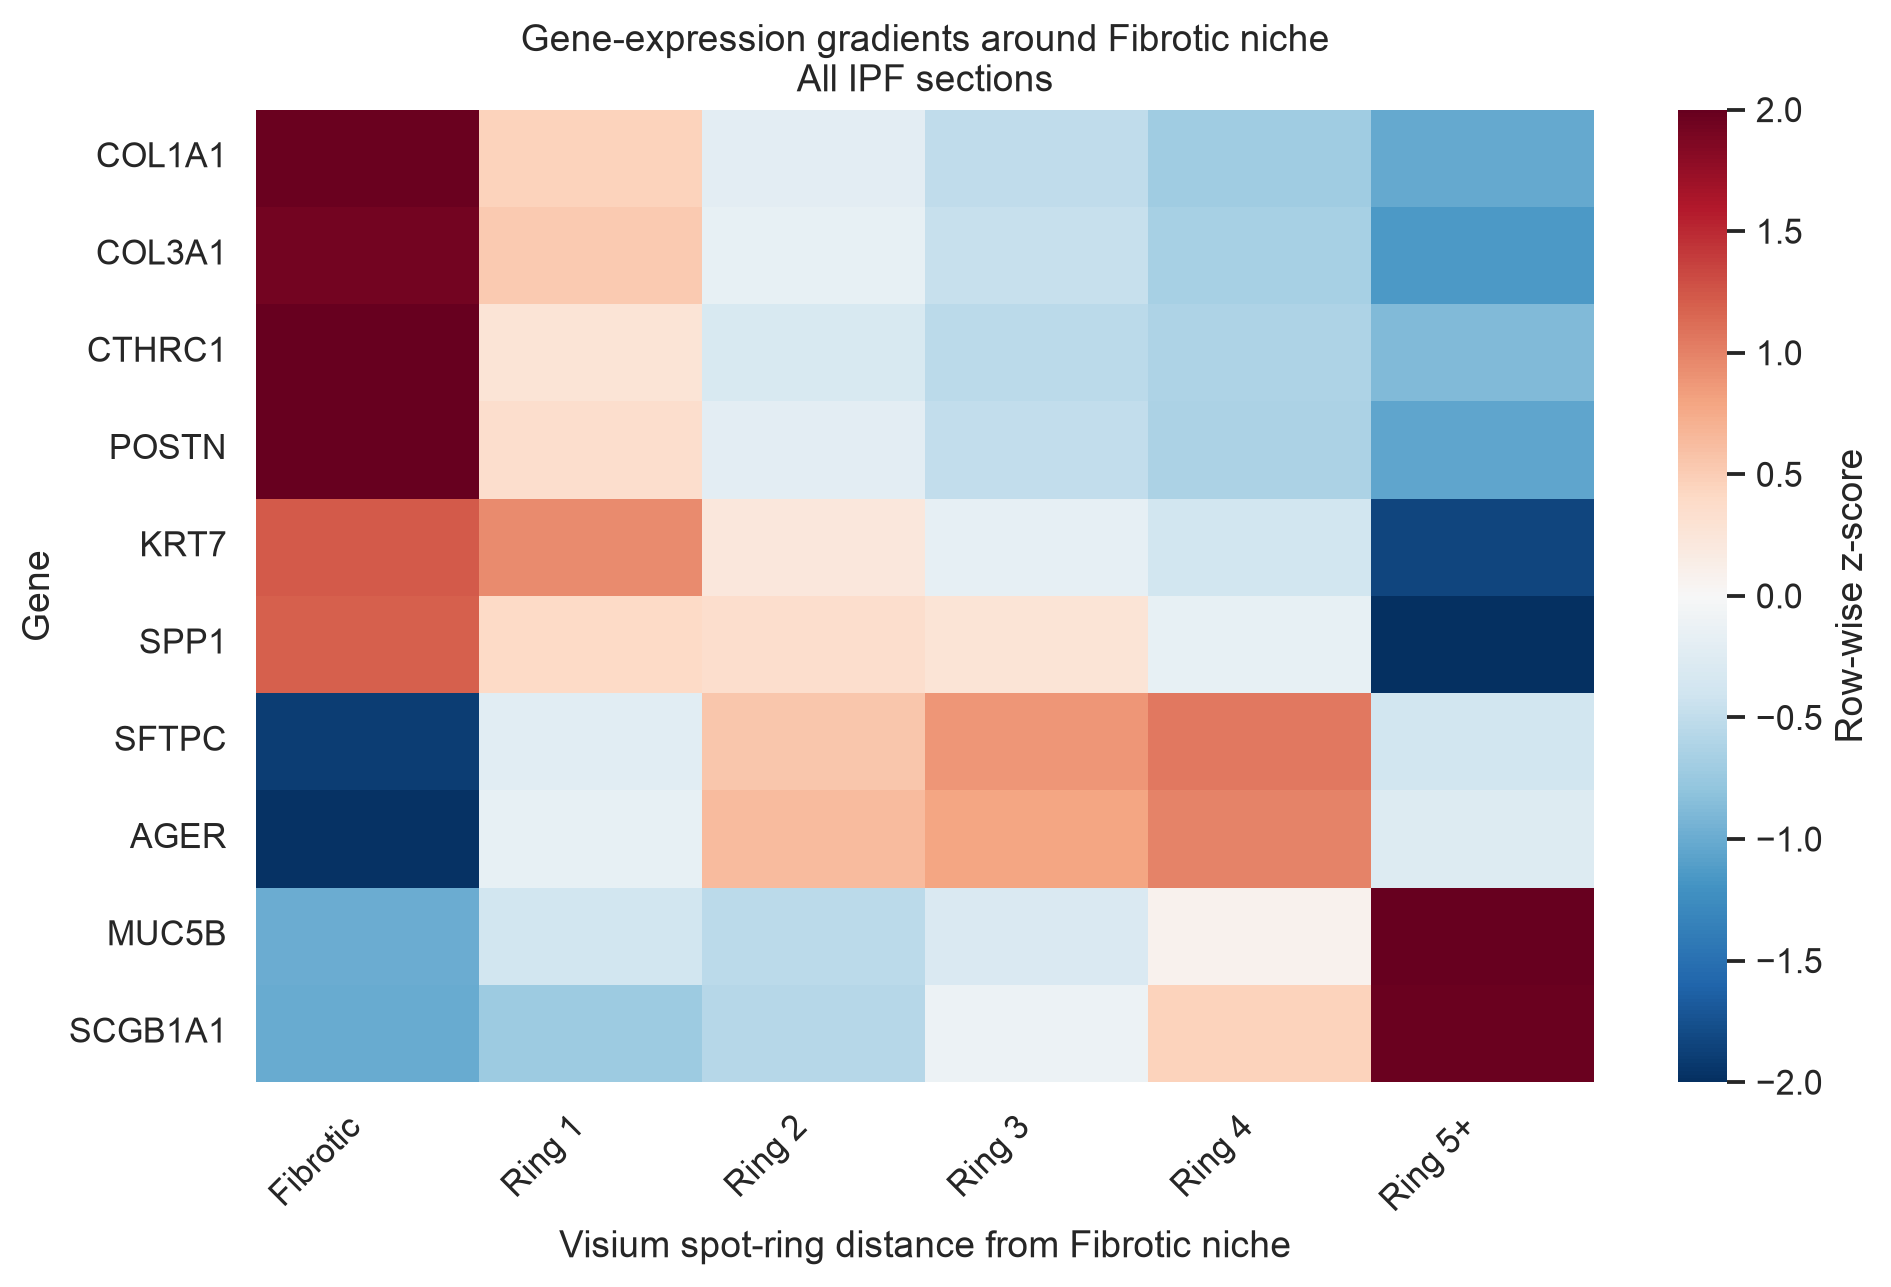

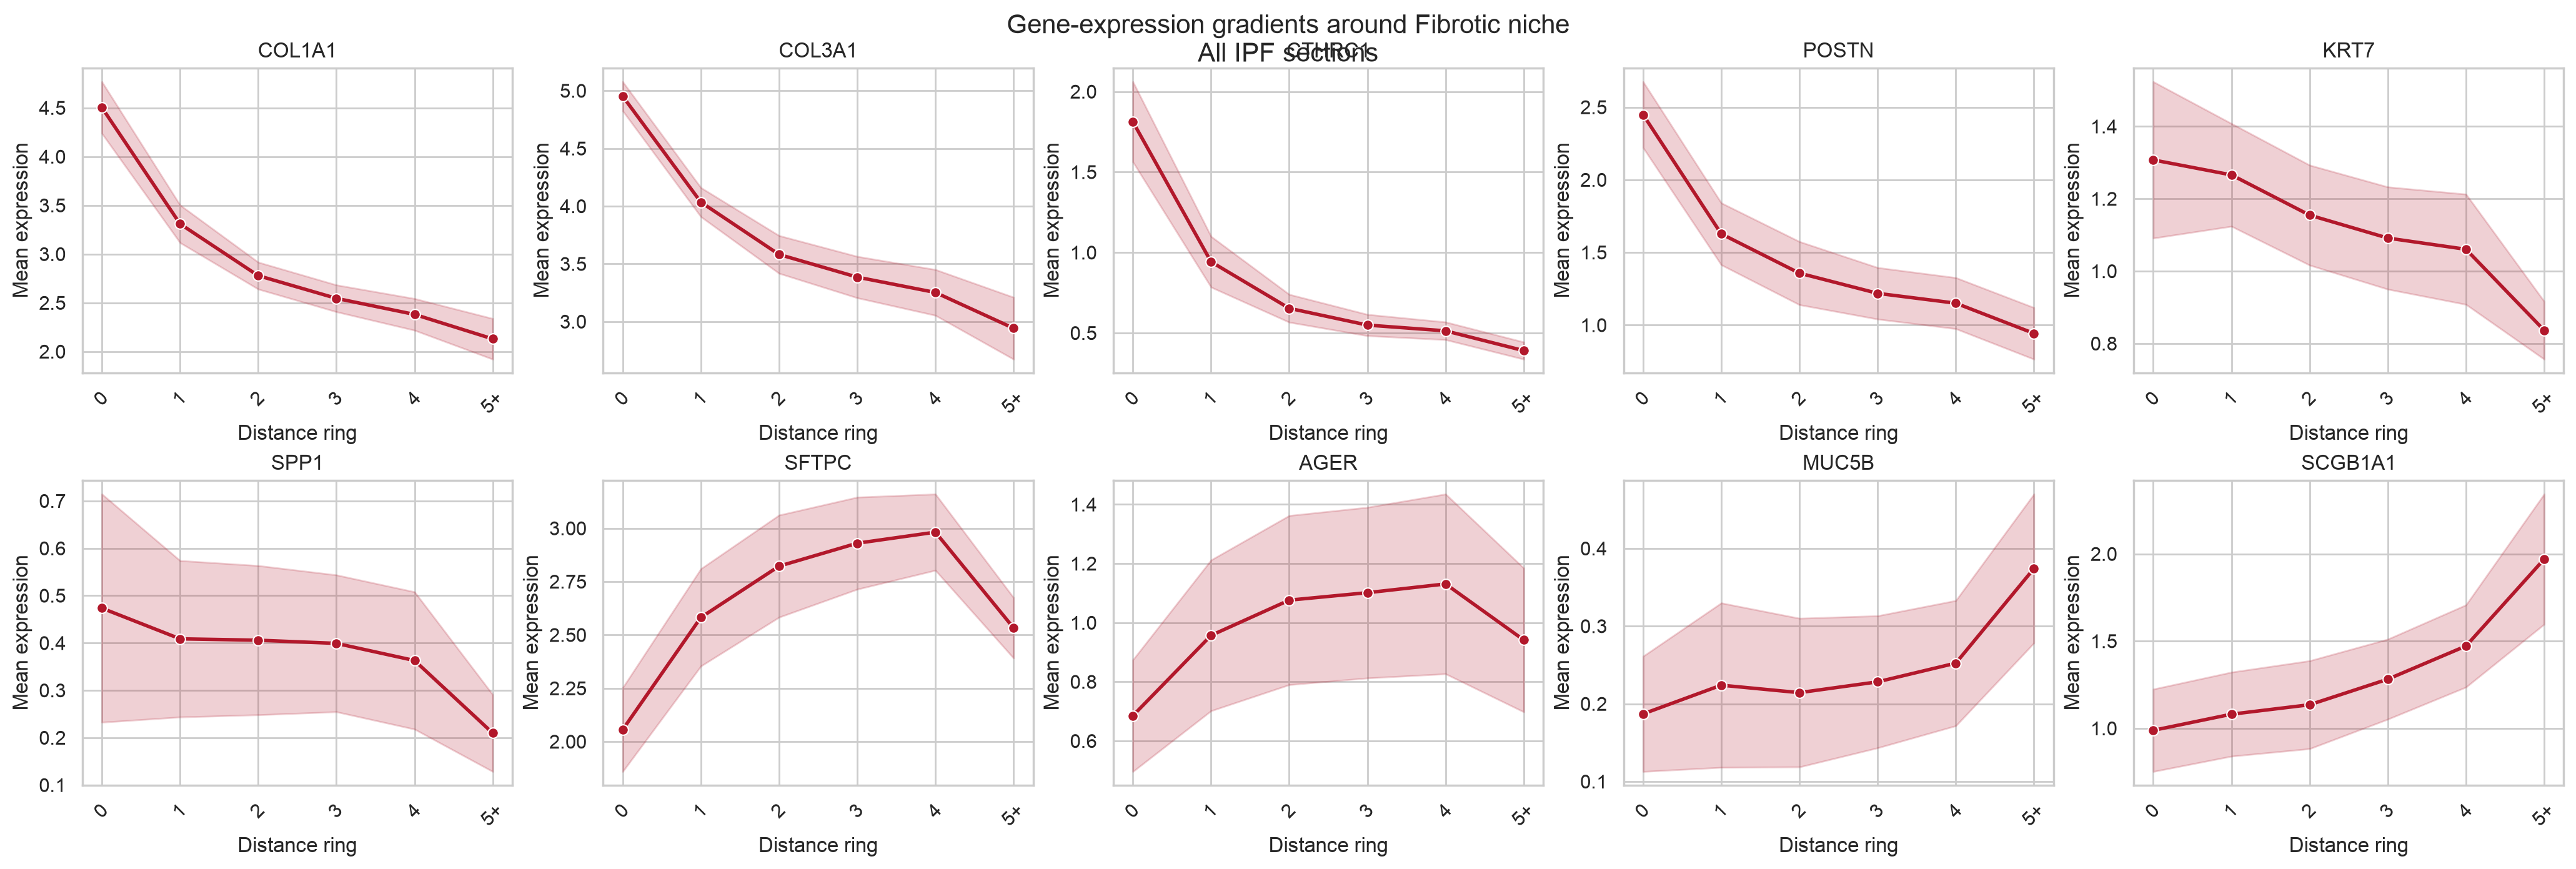

In [53]:
gene_ring_matrix, gene_ring_zscore = plot_ring_heatmap(
    gene_ring_summary,
    feature_column="gene",
    value_column="mean_expression",
    feature_order=genes,
    title="Gene-expression gradients around Fibrotic niche",
    ylabel="Gene",
    figsize=(9, 6),
)

plot_selected_ring_lines(
    gene_ring_summary,
    feature_column="gene",
    value_column="mean_expression",
    feature_order=genes,
    title="Gene-expression gradients around Fibrotic niche",
    ylabel="Mean expression",
    ncols=5,
)

### Biological interpretation

- Fibrosis-associated extracellular-matrix genes `COL1A1`, `COL3A1`, `CTHRC1`, and `POSTN` are highest in the Fibrotic niche and decrease across successive rings. This is consistent with a collagen-rich, activated-stromal program concentrated around fibrotic regions.
- `KRT7` and `SPP1` are also elevated toward the fibrotic side of the gradient, supporting the presence of injury-associated epithelial and macrophage programs near the niche.
- The alveolar markers `SFTPC` and `AGER` are depleted in the Fibrotic core and become relatively higher in intermediate or outer rings, consistent with better-preserved alveolar identity away from the fibrotic center.
- `MUC5B` and `SCGB1A1` show stronger relative expression in more distant rings, suggesting increasing airway/secretory epithelial character outside the fibrotic core.

Because values are averaged within `sample × ring` and displayed as feature-wise z-scores, color represents the spatial profile of each gene—not a comparison of absolute expression levels between different genes.

## Pathway-activity gradients

MLM-derived pathway scores are retrieved from `adata.obsm['mlm_estimate']` and summarized using the same sample-level ring strategy.

In [54]:
pathway_scores = adata.obsm["mlm_estimate"]

if not isinstance(pathway_scores, pd.DataFrame):
    raise TypeError("Expected adata.obsm['mlm_estimate'] to be a pandas DataFrame")

# Display label -> column stored in adata.obsm['mlm_estimate']
pathway_sources = {
    "Androgen": "Androgen",
    "EGFR": "EGFR",
    "Estrogen": "Estrogen",
    "Hypoxia": "Hypoxia",
    "JAK-STAT": "JAK-STAT",
    "MAPK": "MAPK",
    "NFkB": "NFkB",
    "PI3K": "PI3K",
    "TGFb": "TGFb",
    "TNFa": "TNFa",
    "Trail": "Trail",
    "VEGF": "VEGF",
    "WNT": "WNT",
    "p53": "p53",
}
pathway_sources = {
    label: source
    for label, source in pathway_sources.items()
    if source in pathway_scores.columns
}
pathways = list(pathway_sources)

pathway_display_names = {
    "Androgen": "Androgen signaling pathway",
    "EGFR": "EGFR signaling pathway",
    "Estrogen": "Estrogen signaling pathway",
    "Hypoxia": "Hypoxia signaling pathway",
    "JAK-STAT": "JAK-STAT signaling pathway",
    "MAPK": "MAPK signaling pathway",
    "NFkB": "NF-κB signaling pathway",
    "PI3K": "PI3K signaling pathway",
    "TGFb": "TGF-β signaling pathway",
    "TNFa": "TNF-α signaling pathway",
    "Trail": "TRAIL signaling pathway",
    "VEGF": "VEGF signaling pathway",
    "WNT": "WNT signaling pathway",
    "p53": "p53 signaling pathway",
}
pathway_labels = [pathway_display_names[pathway] for pathway in pathways]

pathway_ring_summaries = []

for label, source in pathway_sources.items():
    summary = aggregate_by_sample_and_ring(
        pathway_scores[source],
        "mean_activity",
    )
    summary["pathway"] = label
    pathway_ring_summaries.append(summary)

pathway_ring_summary = pd.concat(pathway_ring_summaries, ignore_index=True)
pathway_ring_summary.head()
pathway_ring_summary["pathway"] = pathway_ring_summary["pathway"].map(pathway_display_names)

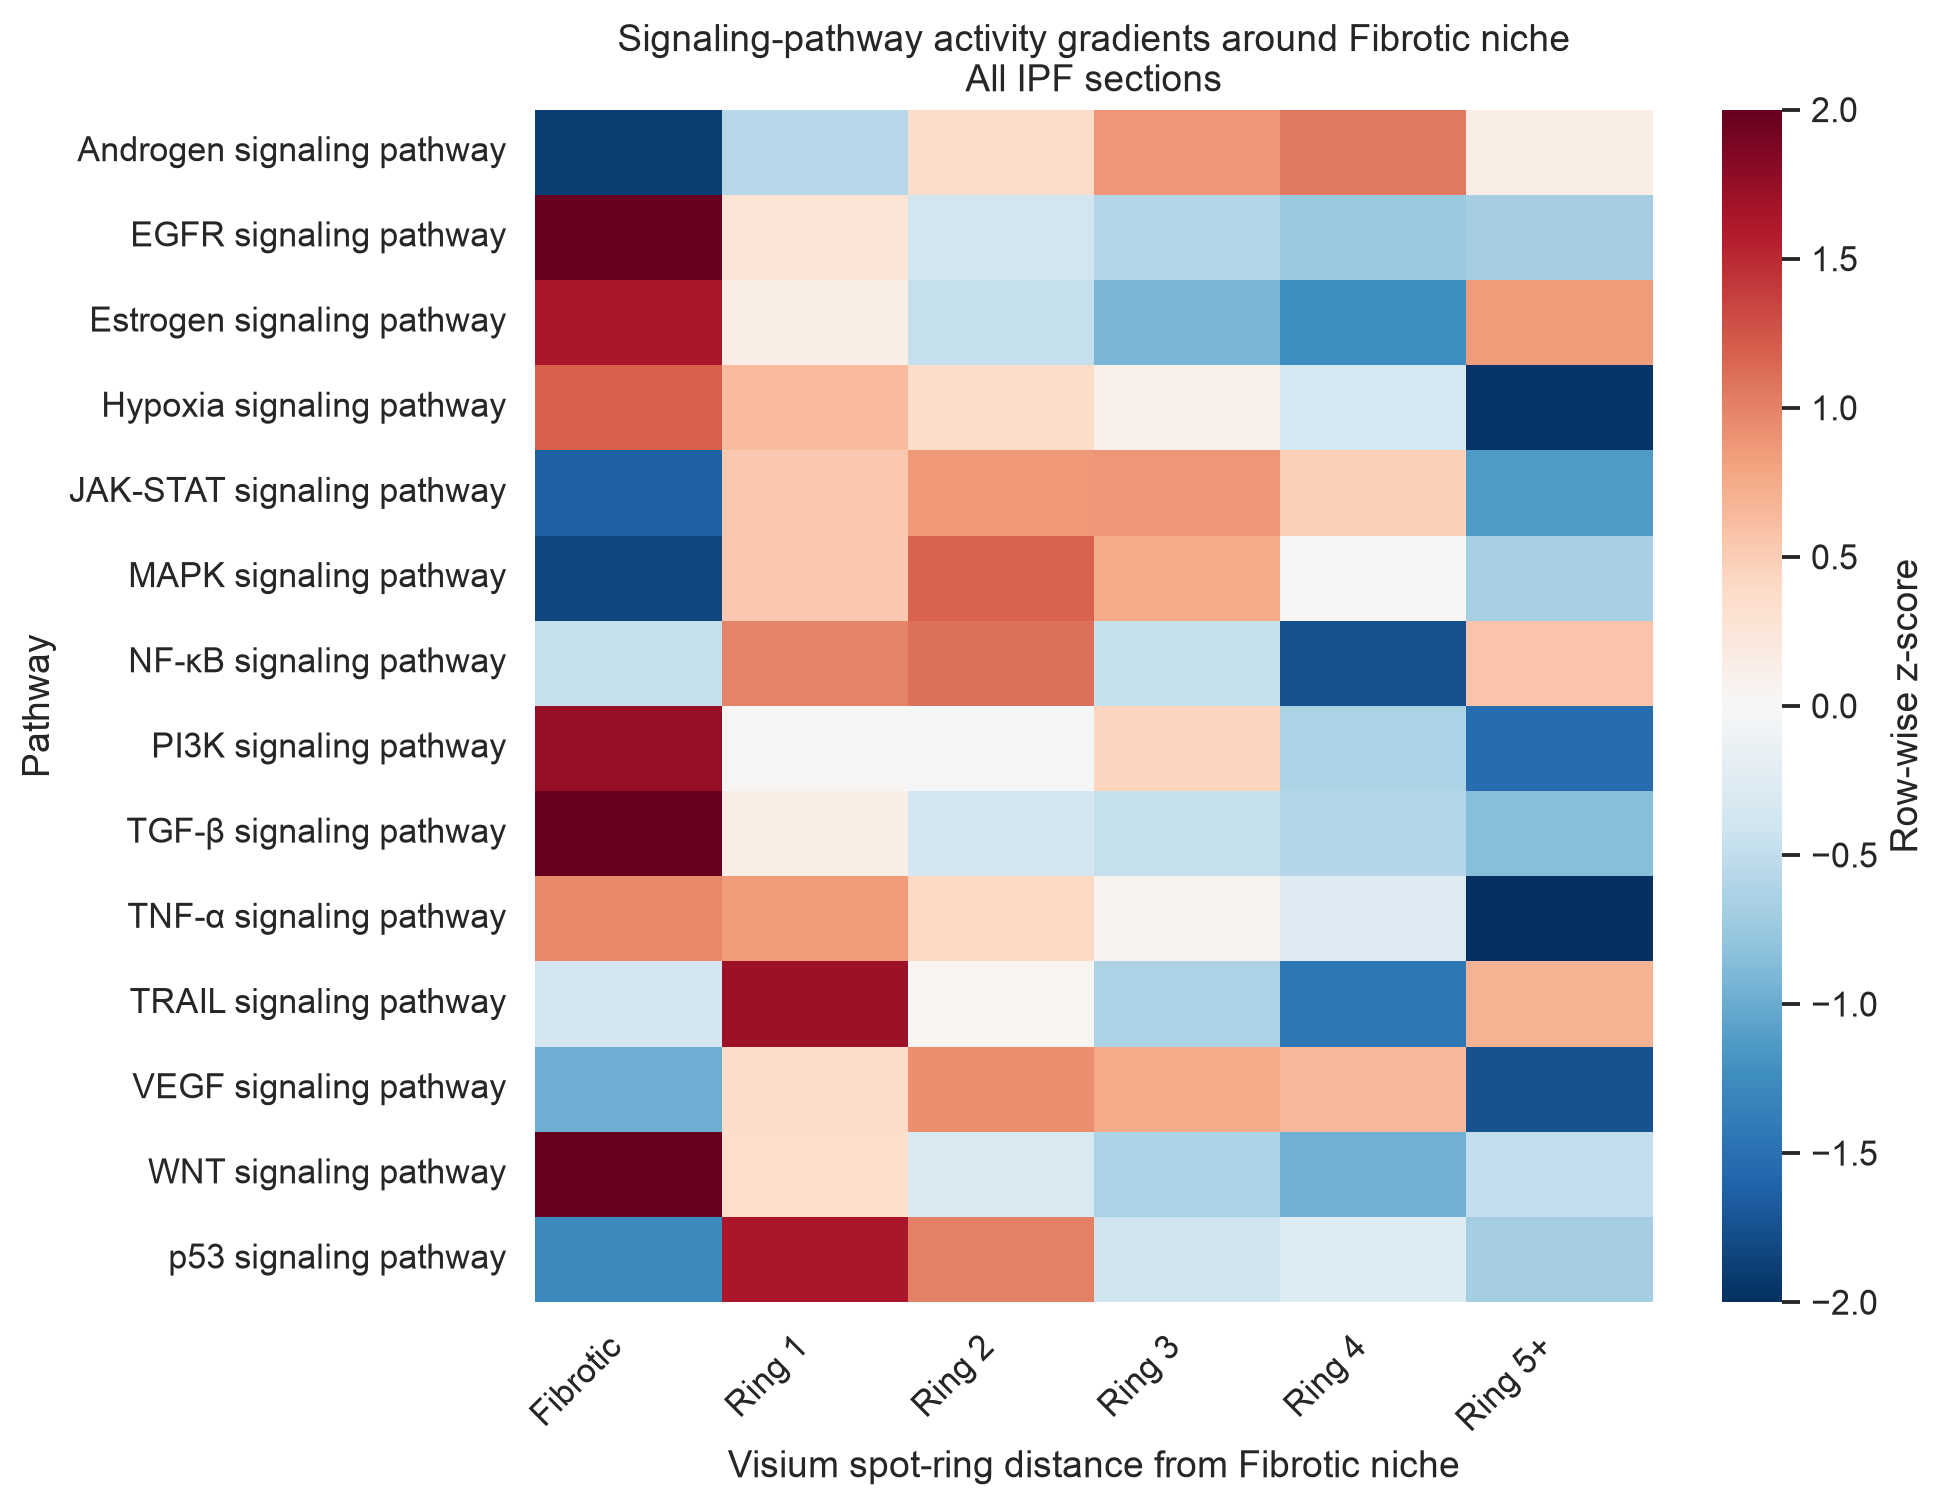

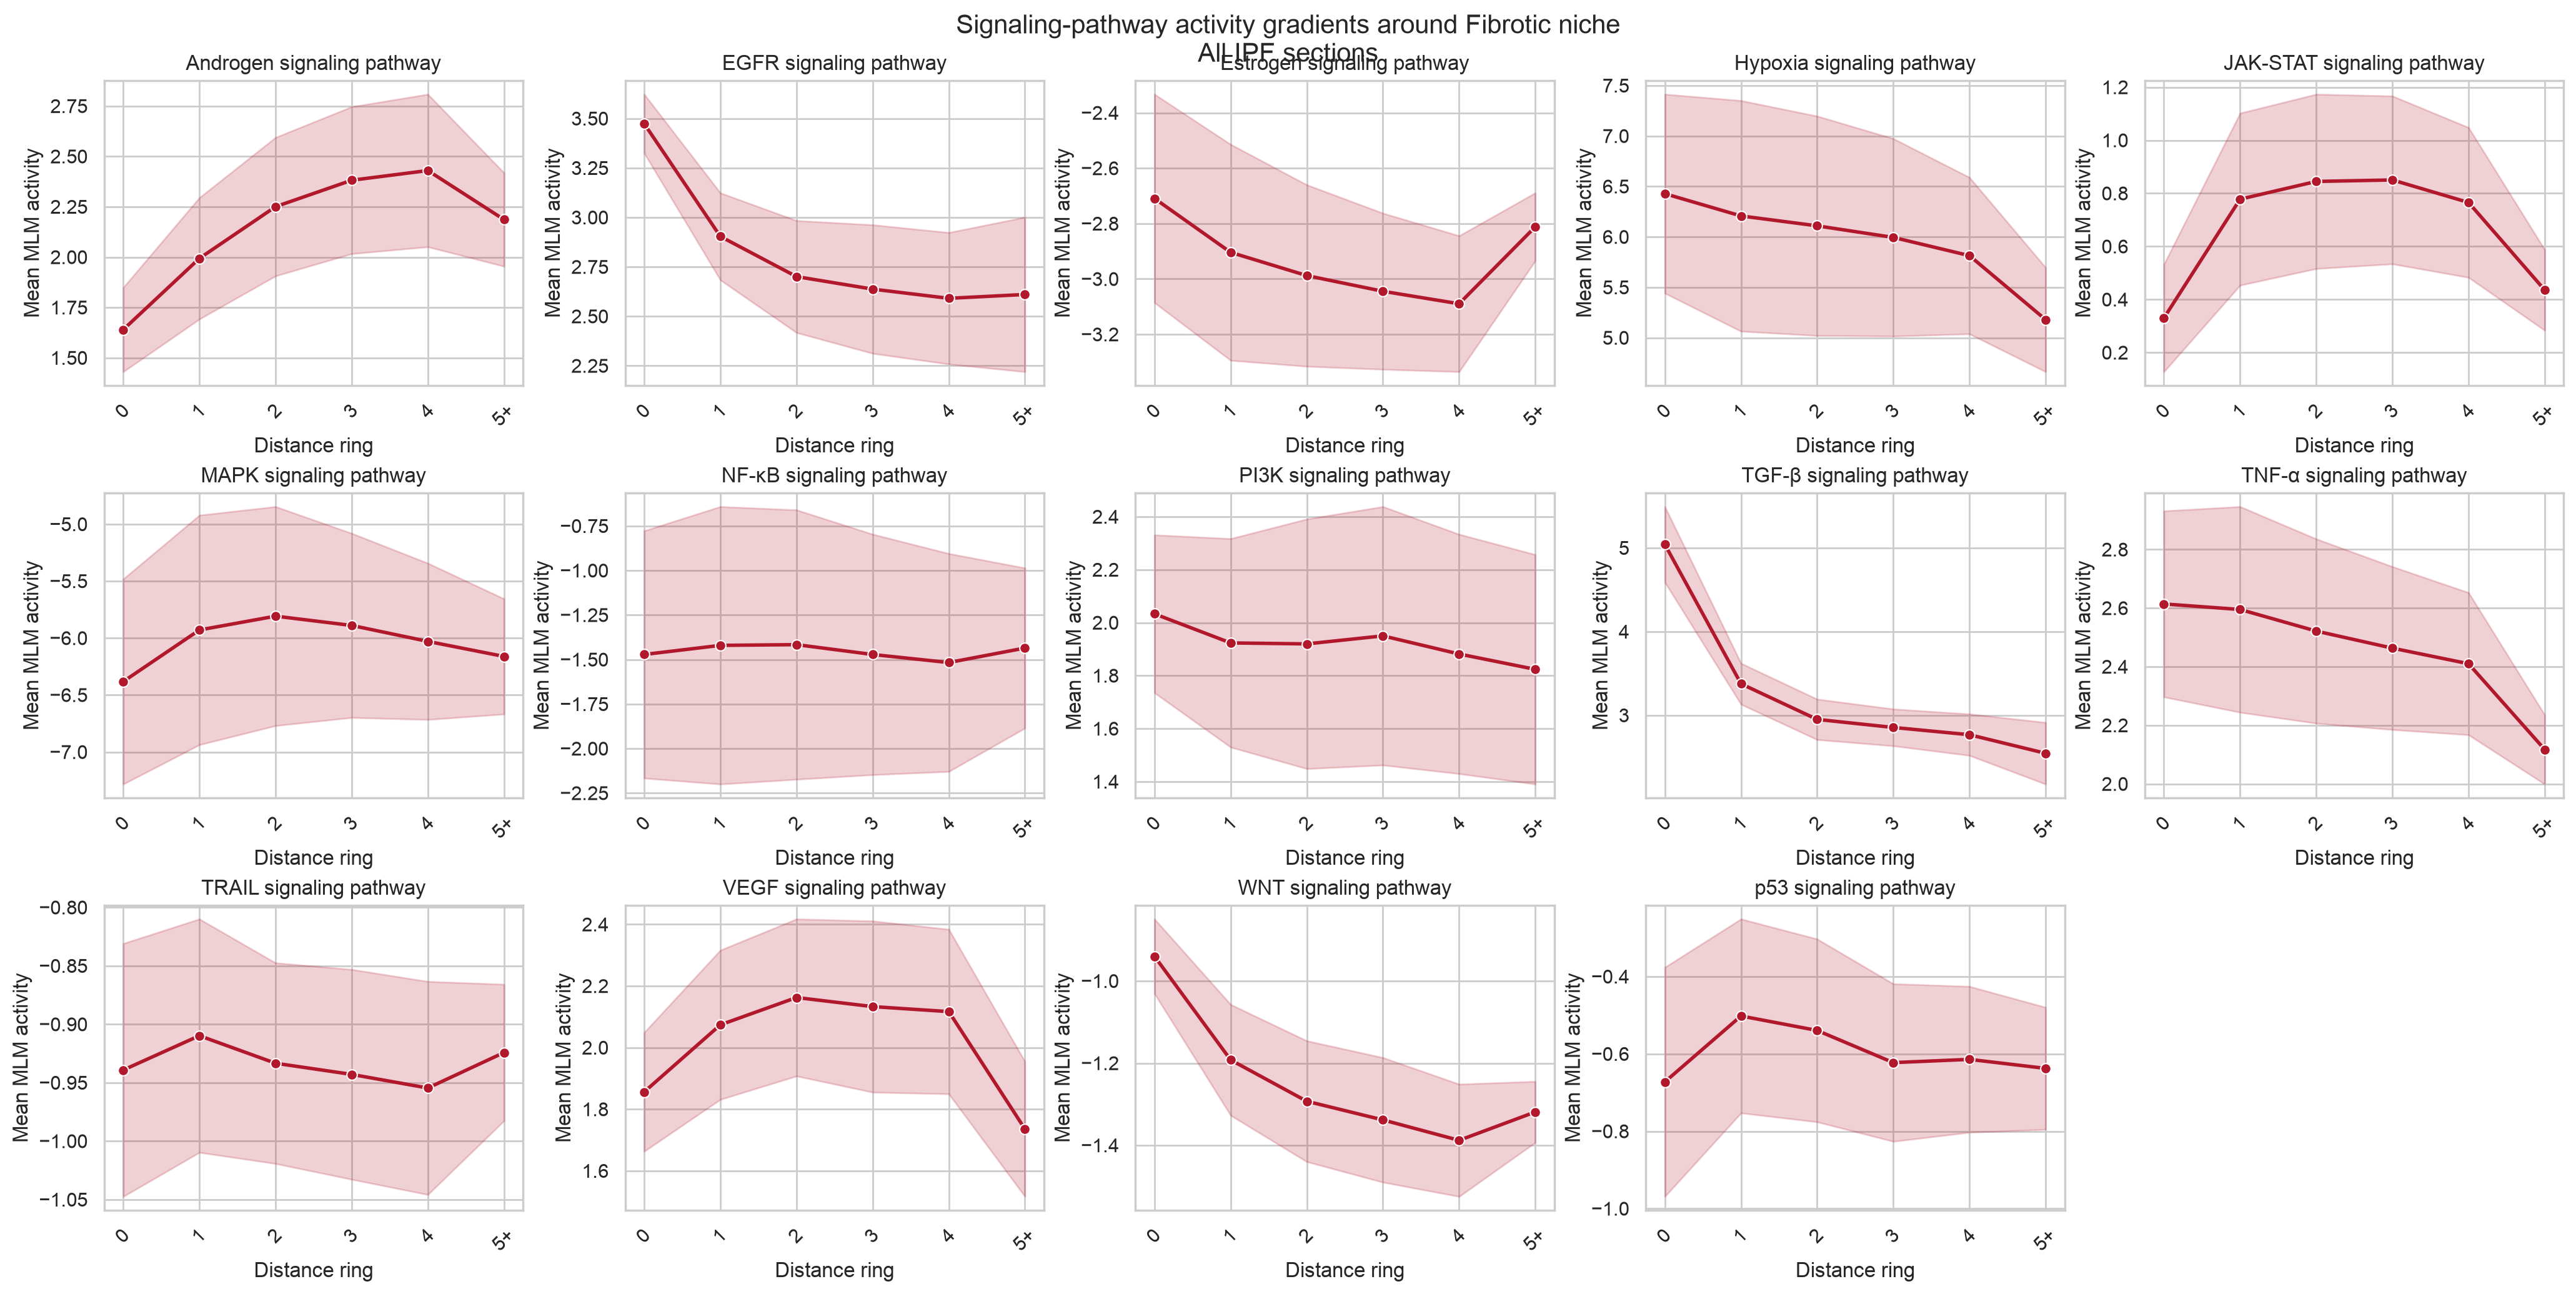

In [55]:
pathway_ring_matrix, pathway_ring_zscore = plot_ring_heatmap(
    pathway_ring_summary,
    feature_column="pathway",
    value_column="mean_activity",
    feature_order=pathway_labels,
    title="Signaling-pathway activity gradients around Fibrotic niche",
    ylabel="Pathway",
    figsize=(9, 7),
)

plot_selected_ring_lines(
    pathway_ring_summary,
    feature_column="pathway",
    value_column="mean_activity",
    feature_order=pathway_labels,
    title="Signaling-pathway activity gradients around Fibrotic niche",
    ylabel="Mean MLM activity",
    ncols=5,
)

### Biological interpretation

- `TGF-β signaling pathway`, `PI3K signaling pathway`, `EGFR signaling pathway`, and `WNT signaling pathway` activity is relatively high in the Fibrotic niche, consistent with profibrotic signaling, tissue remodeling, and altered epithelial–stromal communication.
- `Hypoxia signaling pathway` and `TNF-α signaling pathway` are also elevated toward the fibrotic side and generally decline with distance, suggesting that metabolic stress and inflammatory signaling are spatially concentrated around fibrotic tissue.
- Some pathways peak outside the core or show non-monotonic gradients. For example, `TRAIL signaling pathway`, `NF-κB signaling pathway`, `MAPK signaling pathway`, and `JAK-STAT signaling pathway` vary across intermediate rings rather than following one uniform fibrotic-to-distal trajectory.
- The diversity of profiles indicates that distance from the Fibrotic niche captures several overlapping biological transitions rather than a single coordinated pathway response.

These MLM scores estimate relative pathway activity from gene-expression patterns. They should be interpreted as pathway-associated transcriptional programs, not direct measurements of protein activation.

## Integrated ring-gradient heatmap

For a compact overview, each feature is standardized across rings after sample-level aggregation. Positive values indicate rings with above-average values for that feature; negative values indicate below-average values.

In [56]:
cell_heatmap = cell_ring_zscore.copy()
cell_heatmap.index = "Cell: " + cell_heatmap.index

gene_heatmap = gene_ring_zscore.copy()
gene_heatmap.index = "Gene: " + gene_heatmap.index

pathway_heatmap = pathway_ring_zscore.copy()
pathway_heatmap.index = "Pathway: " + pathway_heatmap.index

integrated_ring_heatmap = pd.concat([
    cell_heatmap,
    gene_heatmap,
    pathway_heatmap,
])

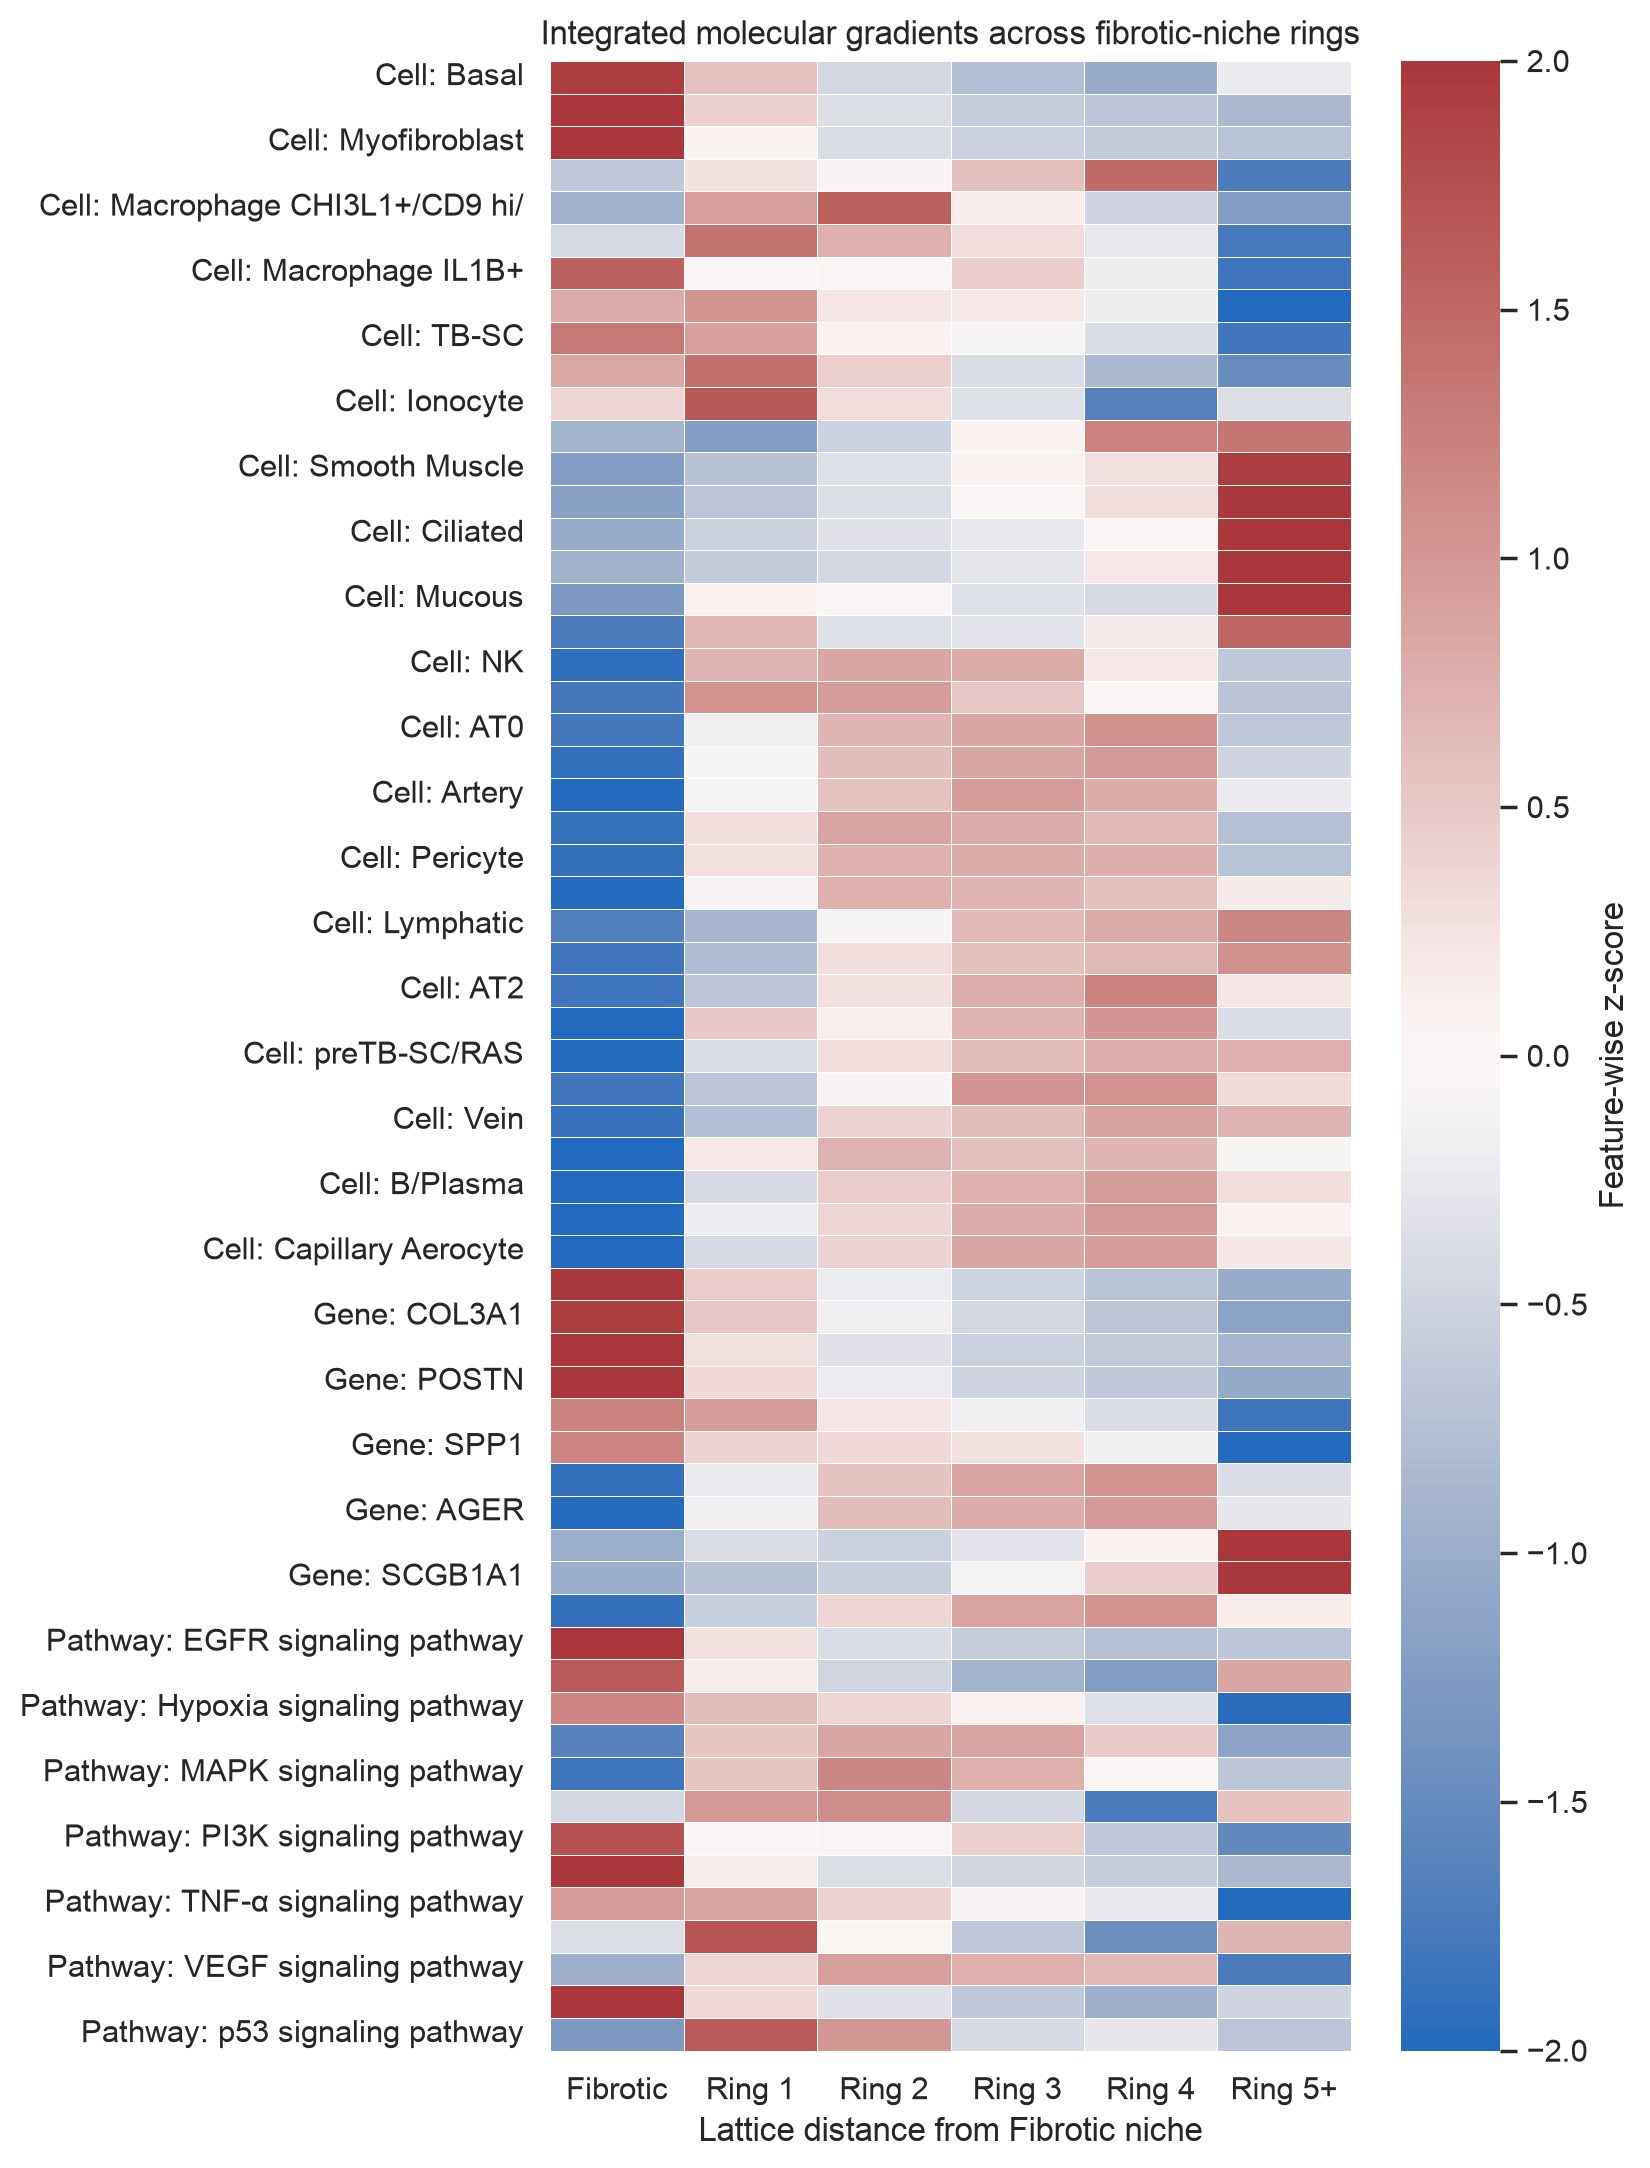

In [57]:
plt.figure(figsize=(8, 11))
sns.heatmap(
    integrated_ring_heatmap,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "Feature-wise z-score"},
)
plt.xlabel("Lattice distance from Fibrotic niche")
plt.ylabel("")
plt.title("Integrated molecular gradients across fibrotic-niche rings")
plt.tight_layout()
plt.show()

### Integrated interpretation

Across cell composition, gene expression, and pathway activity, the Fibrotic niche is characterized by a coherent remodeling program: activated stromal and aberrant epithelial populations, collagen/ECM genes, and profibrotic signaling are concentrated at or near the niche. Moving outward, these features weaken while differentiated alveolar, airway, vascular, and structural tissue programs become more prominent.

The integrated heatmap is descriptive and useful for discovering coordinated gradients. However, fibrotic composition and ring distance are correlated, so this figure cannot determine whether a molecular feature is associated primarily with the local fibrotic state or with spatial distance itself. Notebook 04 addresses that distinction using additive models that adjust each effect for the other and for sample.

## Summary

- Fibrotic-niche proximity was defined using shortest-path distance on the native six-neighbor Visium lattice.
- Ring assignments were calculated independently within each IPF tissue section.
- Cell-type, gene-expression, and pathway gradients were first aggregated within each `sample × ring` before being summarized across sections.
- These descriptive gradients identify candidate readouts for the adjusted models in Notebook 04.

Ring distance alone does not distinguish a spot's local fibrotic composition from its physical proximity to a fibrotic region. Notebook 04 addresses that distinction using the continuous fibrotic NMF score and sample-adjusted models.